# Tiny Graphs - Neural Network (Graph: Grid)

## 1) Tiny grid (High Weight Decay/No Dropout -- Reasonable LR)


In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [2]:
grid_v1_seed = 7

grid_v1_train_from_scratch = True
grid_v1_checkpoint_path = ""
grid_v1_embedding_history_path = ""
grid_v1_topk_history_path = ""
grid_v1_dataset_overwrite = False

grid_v1_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 2, # HIGH WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": False,
}


In [3]:
grid_v1_context = build_transformer_section_context(
    grid_v1_cli_config,
    seed=grid_v1_seed,
    dataset_overwrite=grid_v1_dataset_overwrite,
)

grid_v1_resolved_checkpoint_path = train_or_load_edge_model(
    grid_v1_context,
    train_from_scratch=grid_v1_train_from_scratch,
    checkpoint_path=grid_v1_checkpoint_path,
)

print("Run name:", grid_v1_context.args.run_name)
print("Checkpoint:", grid_v1_resolved_checkpoint_path)
print("Pretrain file:", grid_v1_context.pretrain_path)
print("Train file:", grid_v1_context.train_path)
print("Test file:", grid_v1_context.test_path)
print("Archived checkpoint:", grid_v1_context.checkpoint_path)
print("Embedding history pickle:", grid_v1_context.embedding_history_path)
print("Top-k pickle:", grid_v1_context.topk_history_path)
print("Manifest:", grid_v1_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datas

Edge Epoch 1/1000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]
Edge Epoch 2/1000 | Loss: 3.2188 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 94.48it/s]
Edge Epoch 3/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 92.79it/s]
Edge Epoch 4/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 74.94it/s]
Edge Epoch 5/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 74.27it/s]
Edge Epoch 6/1000 | Loss: 3.2188 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 72.30it/s]
Edge Epoch 7/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 68.84it/s]
Edge Epoch 8/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 71.97it/s]
Edge Epoch 9/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 75.73it/s]
Edge Epoch 10/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 75.53it/s]
Edge Epoch 11/1000 | Loss: 3.2188 | Acc: 16.67%: 100%|███████


Edge accuracy improved to 33.33%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113219/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113219_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 1.1868 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 58.31it/s]



Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113219
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113219_edge_memorization_final.pt
Pretrain file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
Train file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
Test file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_g

In [4]:
grid_v1_eval_metrics = evaluate_edge_and_path(grid_v1_context)

print_evaluation_report("Tiny Grid (V1)", grid_v1_eval_metrics)


Edge Memorization | Loss: 1.1865 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 64.76it/s]


Edge Memorization | Loss: 1.1865 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 124.58it/s]

Tiny Grid (V1) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [5]:
grid_v1_node_embeddings, grid_v1_edge_list, grid_v1_root_node_index = collect_embeddings_and_edges(grid_v1_context)

grid_v1_embedding_history, grid_v1_topk_recovery_history = load_analysis_histories(
    grid_v1_context,
    grid_v1_edge_list,
    embedding_history_path=grid_v1_embedding_history_path,
    topk_history_path=grid_v1_topk_history_path,
)

if not grid_v1_embedding_history:
    grid_v1_embedding_history = {0: grid_v1_node_embeddings}
if not grid_v1_topk_recovery_history:
    grid_v1_topk_recovery_history = {0: grid_v1_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_v1_node_embeddings.shape)
print("Number of edges:", len(grid_v1_edge_list))
print("Root node index:", grid_v1_root_node_index)
print("Embedding history steps:", len(grid_v1_embedding_history))
print("Top-k history steps:", len(grid_v1_topk_recovery_history))


Node embedding shape: (16, 32)
Number of edges: 48
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [6]:
# Reduction config for this block (kept local to reduction stage)
grid_v1_use_umap = False
grid_v1_reduction_dim = 5
grid_v1_umap_n_neighbors = 4
grid_v1_umap_min_dist = 0.3

grid_v1_reduced_full, grid_v1_reduced_embeddings = reduce_embeddings_for_plot(
    grid_v1_node_embeddings,
    use_umap=grid_v1_use_umap,
    reduction_dim=grid_v1_reduction_dim,
    seed=grid_v1_seed,
    umap_n_neighbors=grid_v1_umap_n_neighbors,
    umap_min_dist=grid_v1_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_v1_reduced_embeddings = grid_v1_reduced_full[:, :3]
print("Reduced full shape:", grid_v1_reduced_full.shape)
print("Reduced xyz shape:", grid_v1_reduced_embeddings.shape)


Reduced full shape: (16, 5)
Reduced xyz shape: (16, 3)


### Geometry Plot

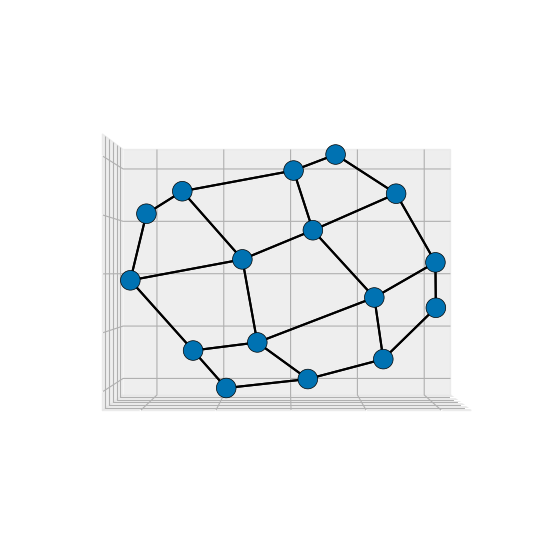

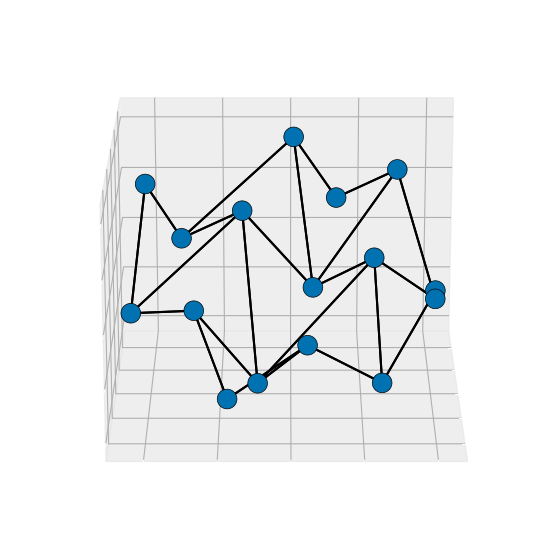

In [7]:
%matplotlib inline
# %matplotlib widget

grid_v1_raw_elev = 0
grid_v1_raw_azim = 0
grid_v1_raw_roll = 0

# Styled plotting constants for this block
grid_v1_styled_view = {"elev": grid_v1_raw_elev, "azim": grid_v1_raw_azim, "roll": grid_v1_raw_roll}
grid_v1_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v1_reduced_embeddings,
    grid_v1_edge_list,
    title="",
    view=grid_v1_styled_view,
    root_node_index=grid_v1_root_node_index,
    axis_permutation=grid_v1_styled_axis_permutation,
);

################
#Another Angle
################

grid_v1_raw_elev = 20
grid_v1_raw_azim = 0
grid_v1_raw_roll = 0

# Styled plotting constants for this block
grid_v1_styled_view = {"elev": grid_v1_raw_elev, "azim": grid_v1_raw_azim, "roll": grid_v1_raw_roll}
grid_v1_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v1_reduced_embeddings,
    grid_v1_edge_list,
    title="",
    view=grid_v1_styled_view,
    root_node_index=grid_v1_root_node_index,
    axis_permutation=grid_v1_styled_axis_permutation,
);


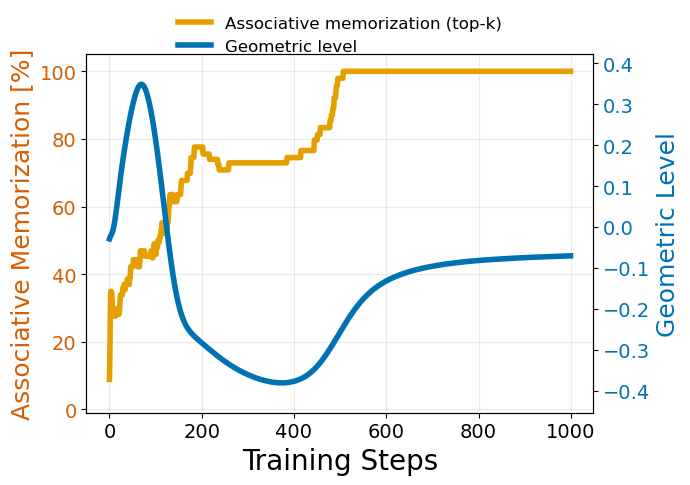

In [8]:
# Line-plot constants for this block
grid_v1_line_plot_title = ""

grid_v1_curve_steps, grid_v1_curve_associative, grid_v1_curve_geometric = compute_associative_geometric_curves(
    grid_v1_embedding_history,
    grid_v1_topk_recovery_history,
    grid_v1_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_v1_curve_steps,
    associative_scores=grid_v1_curve_associative,
    geometric_scores=grid_v1_curve_geometric,
    title=grid_v1_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `grid_heatmap_epoch` to one of the highest geometric_level epochs.

Grid heatmap epoch: 999
Grid heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14 15


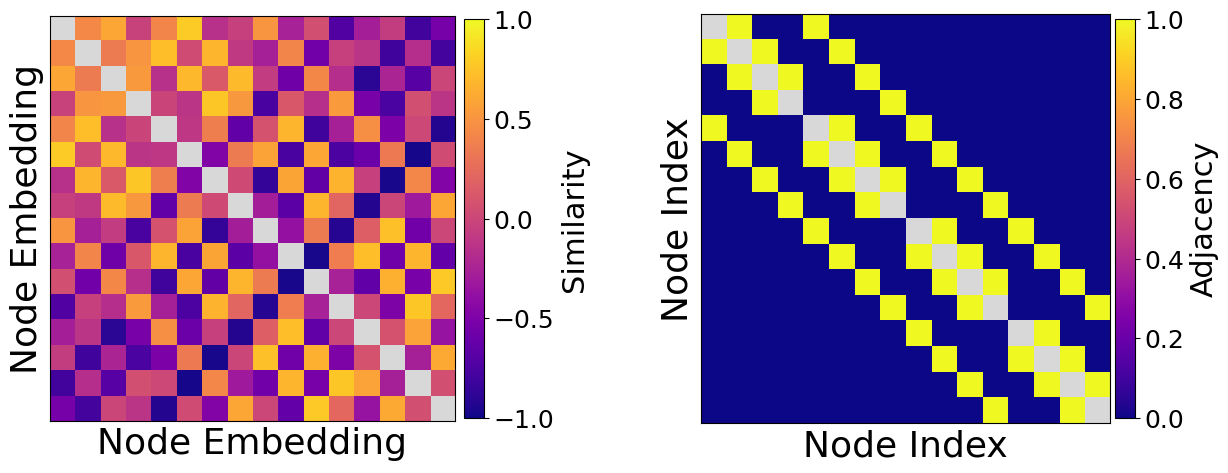

In [9]:
# Heatmap constants for this block
grid_v1_heatmap_graph_type = grid_v1_context.args.graph_type
grid_v1_heatmap_epoch = -1
grid_v1_heatmap_cmap_name = "plasma"
grid_v1_heatmap_wspace = 0.5

grid_v1_heatmap_embeddings, grid_v1_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=grid_v1_embedding_history,
    fallback_embeddings=grid_v1_node_embeddings,
    requested_step=grid_v1_heatmap_epoch,
)
print("Grid heatmap epoch:", grid_v1_heatmap_resolved_epoch)
grid_v1_heatmap_order = list(range(grid_v1_heatmap_embeddings.shape[0]))
print("Grid heatmap order rows:")
for row_start in range(0, len(grid_v1_heatmap_order), 4):
    row = grid_v1_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=grid_v1_heatmap_embeddings,
    edge_list=grid_v1_edge_list,
    graph_type=grid_v1_heatmap_graph_type,
    root_node_index=grid_v1_root_node_index,
    custom_order=grid_v1_heatmap_order,
    cmap_name=grid_v1_heatmap_cmap_name,
    wspace=grid_v1_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [10]:
# Laplacian geometry constants for this block
grid_v1_laplacian_axis_indices = (-2, -3, -4)
grid_v1_spectral_state = build_graph_spectral_state(
    edge_list=grid_v1_edge_list,
    node_count=grid_v1_node_embeddings.shape[0],
)

/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_spectral.py:56: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors = np.asarray(eigenvectors[:, sorted_indices], dtype=np.float64)


Grid normalized eigenvalues:
 [ 1.     1.     0.646  0.423  0.42   0.    -0.    -0.    -0.    -0.42
 -0.423 -0.646 -1.    -1.    -1.274]


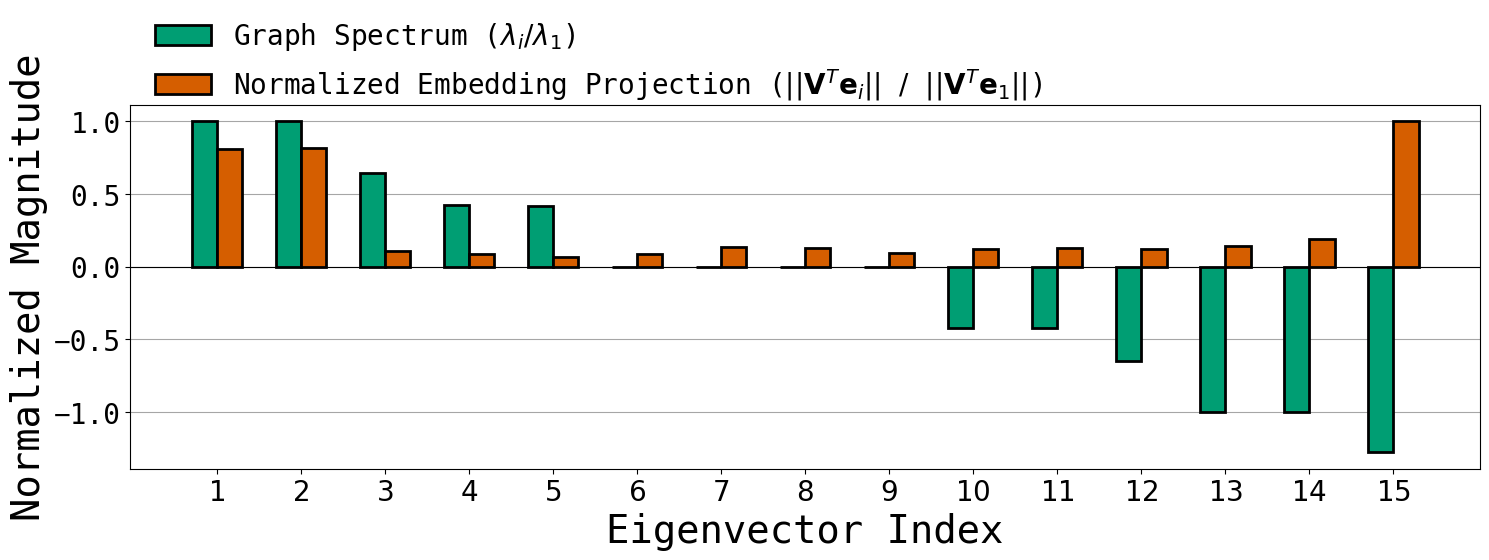

In [11]:
# Spectral-bias constants for this block
grid_v1_spectral_drop_top_eigenvector = True
grid_v1_spectral_reorder_prefix = None
grid_v1_spectral_cutoff = None
grid_v1_spectral_figsize = (15.0, 6.0)
grid_v1_spectral_legend_anchor = (0.0, 1.3)

grid_v1_norm_eigenvalues, grid_v1_norm_projections = compute_spectral_bias_from_state(
    embeddings=grid_v1_node_embeddings,
    spectral_state=grid_v1_spectral_state,
    drop_top_eigenvector=grid_v1_spectral_drop_top_eigenvector,
    reorder_prefix=grid_v1_spectral_reorder_prefix,
)

print("Grid normalized eigenvalues:\n", grid_v1_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=grid_v1_norm_eigenvalues,
    norm_projections=grid_v1_norm_projections,
    title="",
    cutoff=grid_v1_spectral_cutoff,
    figsize=grid_v1_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=grid_v1_spectral_legend_anchor,
    save=True,
    filename=f"{grid_v1_context.args.graph_type}_{grid_v1_context.args.model_architecture_label}_eigen_projection_v1"
);


## 2) Tiny grid (High Dropout/No Weight Decay -- Reasonable LR)


In [12]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [29]:
grid_v2_seed = 7

grid_v2_train_from_scratch = True
grid_v2_checkpoint_path = ""
grid_v2_embedding_history_path = ""
grid_v2_topk_history_path = ""
grid_v2_dataset_overwrite = False

grid_v2_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.1, # WITH DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": False,
}


In [30]:
grid_v2_context = build_transformer_section_context(
    grid_v2_cli_config,
    seed=grid_v2_seed,
    dataset_overwrite=grid_v2_dataset_overwrite,
)

grid_v2_resolved_checkpoint_path = train_or_load_edge_model(
    grid_v2_context,
    train_from_scratch=grid_v2_train_from_scratch,
    checkpoint_path=grid_v2_checkpoint_path,
)

print("Run name:", grid_v2_context.args.run_name)
print("Checkpoint:", grid_v2_resolved_checkpoint_path)
print("Pretrain file:", grid_v2_context.pretrain_path)
print("Train file:", grid_v2_context.train_path)
print("Test file:", grid_v2_context.test_path)
print("Archived checkpoint:", grid_v2_context.checkpoint_path)
print("Embedding history pickle:", grid_v2_context.embedding_history_path)
print("Top-k pickle:", grid_v2_context.topk_history_path)
print("Manifest:", grid_v2_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datas

Edge Epoch 1/1000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 78.27it/s]
Edge Epoch 2/1000 | Loss: 3.2188 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 47.66it/s]
Edge Epoch 3/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 58.94it/s]
Edge Epoch 4/1000 | Loss: 3.2188 | Acc: 16.67%: 100%|██████████| 1/1 [00:00<00:00, 51.13it/s]
Edge Epoch 5/1000 | Loss: 3.2188 | Acc: 18.75%: 100%|██████████| 1/1 [00:00<00:00, 44.50it/s]
Edge Epoch 6/1000 | Loss: 3.2188 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 39.45it/s]
Edge Epoch 7/1000 | Loss: 3.2188 | Acc: 20.83%: 100%|██████████| 1/1 [00:00<00:00, 56.53it/s]
Edge Epoch 8/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 45.71it/s]
Edge Epoch 9/1000 | Loss: 3.2188 | Acc: 18.75%: 100%|██████████| 1/1 [00:00<00:00, 47.16it/s]
Edge Epoch 10/1000 | Loss: 3.2188 | Acc: 20.83%: 100%|██████████| 1/1 [00:00<00:00, 71.20it/s]
Edge Epoch 11/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|███████


Edge accuracy improved to 33.33%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113457/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113457_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 1.1937 | Acc: 27.08%: 100%|██████████| 1/1 [00:00<00:00, 72.14it/s]



Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113457
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113457_edge_memorization_final.pt
Pretrain file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
Train file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
Test file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_g

In [31]:
grid_v2_eval_metrics = evaluate_edge_and_path(grid_v2_context)

print_evaluation_report("Tiny Grid (V2)", grid_v2_eval_metrics)


Edge Memorization | Loss: 1.1484 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 51.86it/s]


Edge Memorization | Loss: 1.1484 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 109.04it/s]

Tiny Grid (V2) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [32]:
grid_v2_node_embeddings, grid_v2_edge_list, grid_v2_root_node_index = collect_embeddings_and_edges(grid_v2_context)

grid_v2_embedding_history, grid_v2_topk_recovery_history = load_analysis_histories(
    grid_v2_context,
    grid_v2_edge_list,
    embedding_history_path=grid_v2_embedding_history_path,
    topk_history_path=grid_v2_topk_history_path,
)

if not grid_v2_embedding_history:
    grid_v2_embedding_history = {0: grid_v2_node_embeddings}
if not grid_v2_topk_recovery_history:
    grid_v2_topk_recovery_history = {0: grid_v2_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_v2_node_embeddings.shape)
print("Number of edges:", len(grid_v2_edge_list))
print("Root node index:", grid_v2_root_node_index)
print("Embedding history steps:", len(grid_v2_embedding_history))
print("Top-k history steps:", len(grid_v2_topk_recovery_history))


Node embedding shape: (16, 32)
Number of edges: 48
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [33]:
# Reduction config for this block (kept local to reduction stage)
grid_v2_use_umap = False
grid_v2_reduction_dim = 5
grid_v2_umap_n_neighbors = 4
grid_v2_umap_min_dist = 0.3

grid_v2_reduced_full, grid_v2_reduced_embeddings = reduce_embeddings_for_plot(
    grid_v2_node_embeddings,
    use_umap=grid_v2_use_umap,
    reduction_dim=grid_v2_reduction_dim,
    seed=grid_v2_seed,
    umap_n_neighbors=grid_v2_umap_n_neighbors,
    umap_min_dist=grid_v2_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_v2_reduced_embeddings = grid_v2_reduced_full[:, :3]
print("Reduced full shape:", grid_v2_reduced_full.shape)
print("Reduced xyz shape:", grid_v2_reduced_embeddings.shape)


Reduced full shape: (16, 5)
Reduced xyz shape: (16, 3)


### Geometry Plot

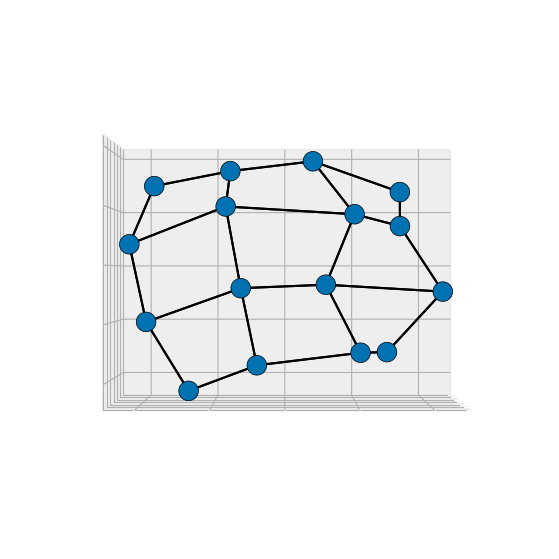

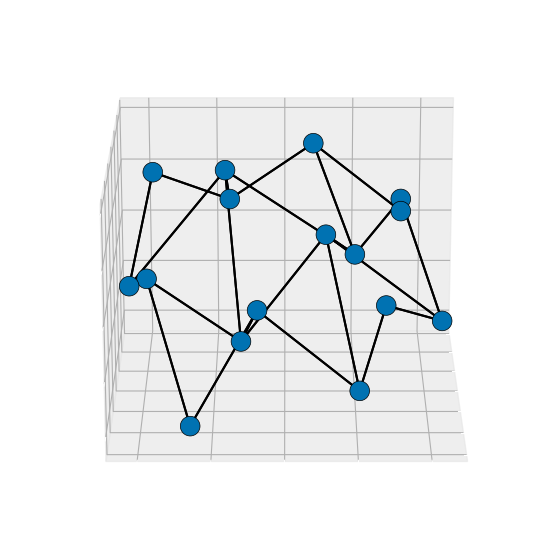

In [34]:
%matplotlib inline
# %matplotlib widget

grid_v2_raw_elev = 0
grid_v2_raw_azim = 0
grid_v2_raw_roll = 0

# Styled plotting constants for this block
grid_v2_styled_view = {"elev": grid_v2_raw_elev, "azim": grid_v2_raw_azim, "roll": grid_v2_raw_roll}
grid_v2_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v2_reduced_embeddings,
    grid_v2_edge_list,
    title="",
    view=grid_v2_styled_view,
    root_node_index=grid_v2_root_node_index,
    axis_permutation=grid_v2_styled_axis_permutation,
);

################
#Another Angle
################

grid_v2_raw_elev = 20
grid_v2_raw_azim = 0
grid_v2_raw_roll = 0

# Styled plotting constants for this block
grid_v2_styled_view = {"elev": grid_v2_raw_elev, "azim": grid_v2_raw_azim, "roll": grid_v2_raw_roll}
grid_v2_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v2_reduced_embeddings,
    grid_v2_edge_list,
    title="",
    view=grid_v2_styled_view,
    root_node_index=grid_v2_root_node_index,
    axis_permutation=grid_v2_styled_axis_permutation,
);


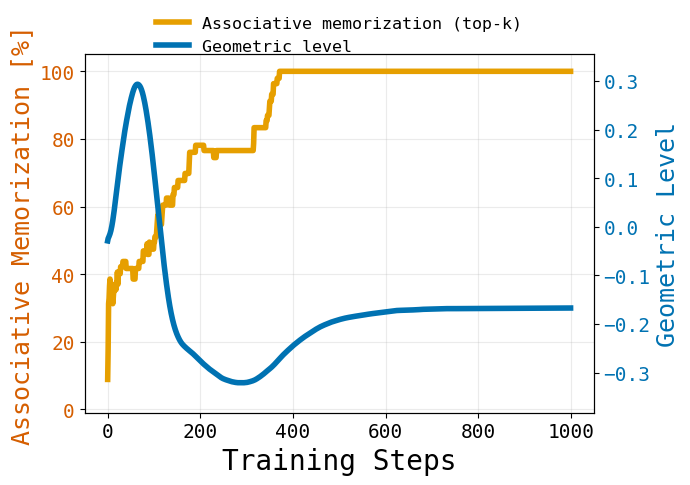

In [35]:
# Line-plot constants for this block
grid_v2_line_plot_title = ""

grid_v2_curve_steps, grid_v2_curve_associative, grid_v2_curve_geometric = compute_associative_geometric_curves(
    grid_v2_embedding_history,
    grid_v2_topk_recovery_history,
    grid_v2_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_v2_curve_steps,
    associative_scores=grid_v2_curve_associative,
    geometric_scores=grid_v2_curve_geometric,
    title=grid_v2_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `grid_heatmap_epoch` to one of the highest geometric_level epochs.

Grid heatmap epoch: 999
Grid heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14 15


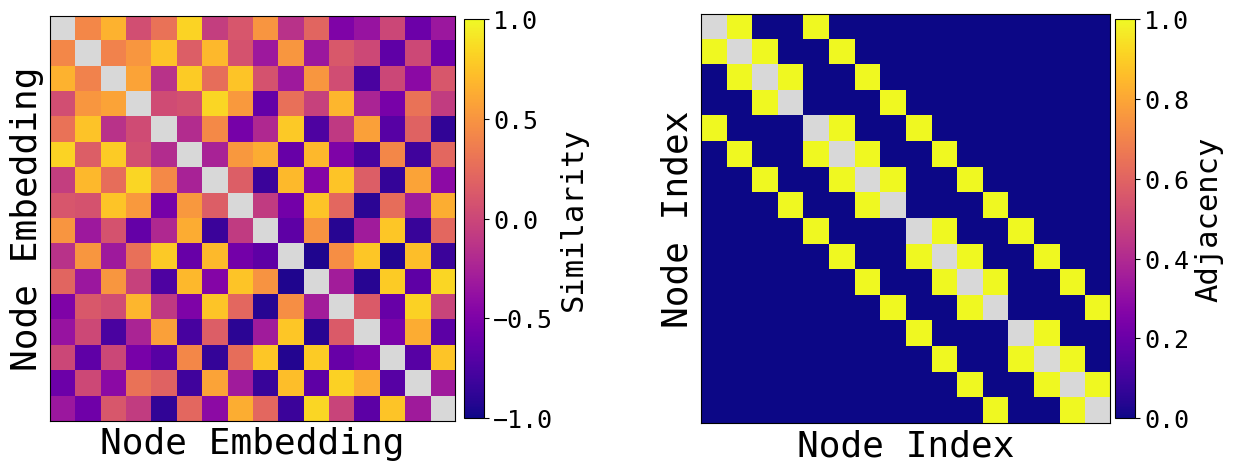

In [36]:
# Heatmap constants for this block
grid_v2_heatmap_graph_type = grid_v2_context.args.graph_type
grid_v2_heatmap_epoch = -1
grid_v2_heatmap_cmap_name = "plasma"
grid_v2_heatmap_wspace = 0.5

grid_v2_heatmap_embeddings, grid_v2_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=grid_v2_embedding_history,
    fallback_embeddings=grid_v2_node_embeddings,
    requested_step=grid_v2_heatmap_epoch,
)
print("Grid heatmap epoch:", grid_v2_heatmap_resolved_epoch)
grid_v2_heatmap_order = list(range(grid_v2_heatmap_embeddings.shape[0]))
print("Grid heatmap order rows:")
for row_start in range(0, len(grid_v2_heatmap_order), 4):
    row = grid_v2_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=grid_v2_heatmap_embeddings,
    edge_list=grid_v2_edge_list,
    graph_type=grid_v2_heatmap_graph_type,
    root_node_index=grid_v2_root_node_index,
    custom_order=grid_v2_heatmap_order,
    cmap_name=grid_v2_heatmap_cmap_name,
    wspace=grid_v2_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [37]:
# Laplacian geometry constants for this block
grid_v2_laplacian_axis_indices = (-2, -3, -4)
grid_v2_spectral_state = build_graph_spectral_state(
    edge_list=grid_v2_edge_list,
    node_count=grid_v2_node_embeddings.shape[0],
)

/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_spectral.py:56: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors = np.asarray(eigenvectors[:, sorted_indices], dtype=np.float64)


Grid normalized eigenvalues:
 [ 1.     1.     0.646  0.423  0.42   0.    -0.    -0.    -0.    -0.42
 -0.423 -0.646 -1.    -1.    -1.274]


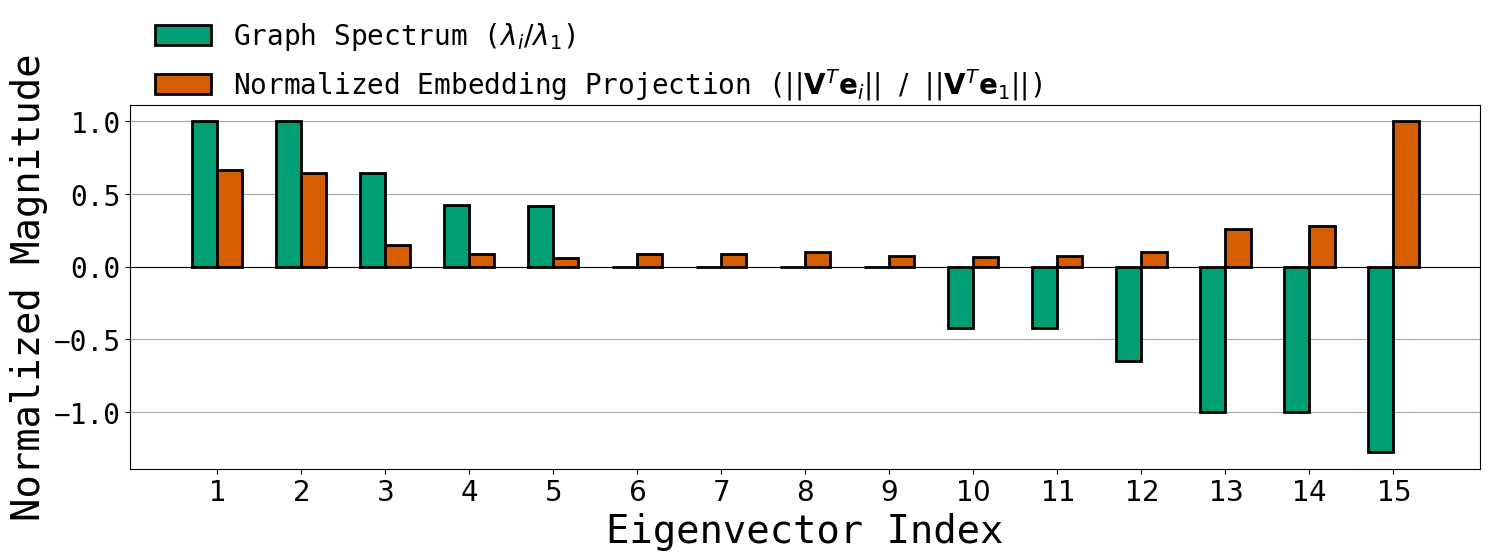

In [38]:
# Spectral-bias constants for this block
grid_v2_spectral_drop_top_eigenvector = True
grid_v2_spectral_reorder_prefix = None
grid_v2_spectral_cutoff = None
grid_v2_spectral_figsize = (15.0, 6.0)
grid_v2_spectral_legend_anchor = (0.0, 1.3)

grid_v2_norm_eigenvalues, grid_v2_norm_projections = compute_spectral_bias_from_state(
    embeddings=grid_v2_node_embeddings,
    spectral_state=grid_v2_spectral_state,
    drop_top_eigenvector=grid_v2_spectral_drop_top_eigenvector,
    reorder_prefix=grid_v2_spectral_reorder_prefix,
)

print("Grid normalized eigenvalues:\n", grid_v2_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=grid_v2_norm_eigenvalues,
    norm_projections=grid_v2_norm_projections,
    title="",
    cutoff=grid_v2_spectral_cutoff,
    figsize=grid_v2_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=grid_v2_spectral_legend_anchor,
    save=True,
    filename=f"{grid_v2_context.args.graph_type}_{grid_v2_context.args.model_architecture_label}_eigen_projection_v2"
);


## 3) Tiny grid (No Weight Decay/Dropout -- Reasonable LR)


In [39]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [40]:
grid_v3_seed = 7

grid_v3_train_from_scratch = True
grid_v3_checkpoint_path = ""
grid_v3_embedding_history_path = ""
grid_v3_topk_history_path = ""
grid_v3_dataset_overwrite = False

grid_v3_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0., # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": False,
}


In [41]:
grid_v3_context = build_transformer_section_context(
    grid_v3_cli_config,
    seed=grid_v3_seed,
    dataset_overwrite=grid_v3_dataset_overwrite,
)

grid_v3_resolved_checkpoint_path = train_or_load_edge_model(
    grid_v3_context,
    train_from_scratch=grid_v3_train_from_scratch,
    checkpoint_path=grid_v3_checkpoint_path,
)

print("Run name:", grid_v3_context.args.run_name)
print("Checkpoint:", grid_v3_resolved_checkpoint_path)
print("Pretrain file:", grid_v3_context.pretrain_path)
print("Train file:", grid_v3_context.train_path)
print("Test file:", grid_v3_context.test_path)
print("Archived checkpoint:", grid_v3_context.checkpoint_path)
print("Embedding history pickle:", grid_v3_context.embedding_history_path)
print("Top-k pickle:", grid_v3_context.topk_history_path)
print("Manifest:", grid_v3_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datas

Edge Epoch 1/1000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 48.24it/s]
Edge Epoch 2/1000 | Loss: 3.2188 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 44.48it/s]
Edge Epoch 3/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 47.72it/s]
Edge Epoch 4/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 45.29it/s]
Edge Epoch 5/1000 | Loss: 3.2188 | Acc: 10.42%: 100%|██████████| 1/1 [00:00<00:00, 49.98it/s]
Edge Epoch 6/1000 | Loss: 3.2188 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 60.50it/s]
Edge Epoch 7/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 59.36it/s]
Edge Epoch 8/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 63.39it/s]
Edge Epoch 9/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 54.27it/s]
Edge Epoch 10/1000 | Loss: 3.2188 | Acc: 14.58%: 100%|██████████| 1/1 [00:00<00:00, 43.40it/s]
Edge Epoch 11/1000 | Loss: 3.2188 | Acc: 16.67%: 100%|███████


Edge accuracy improved to 33.33%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113709/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113709_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 1.1335 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 61.77it/s]



Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113709
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113709_edge_memorization_final.pt
Pretrain file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
Train file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
Test file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_g

In [42]:
grid_v3_eval_metrics = evaluate_edge_and_path(grid_v3_context)

print_evaluation_report("Tiny Grid (V3)", grid_v3_eval_metrics)


Edge Memorization | Loss: 1.1333 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 38.20it/s]


Edge Memorization | Loss: 1.1333 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 96.06it/s]

Tiny Grid (V3) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [43]:
grid_v3_node_embeddings, grid_v3_edge_list, grid_v3_root_node_index = collect_embeddings_and_edges(grid_v3_context)

grid_v3_embedding_history, grid_v3_topk_recovery_history = load_analysis_histories(
    grid_v3_context,
    grid_v3_edge_list,
    embedding_history_path=grid_v3_embedding_history_path,
    topk_history_path=grid_v3_topk_history_path,
)

if not grid_v3_embedding_history:
    grid_v3_embedding_history = {0: grid_v3_node_embeddings}
if not grid_v3_topk_recovery_history:
    grid_v3_topk_recovery_history = {0: grid_v3_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_v3_node_embeddings.shape)
print("Number of edges:", len(grid_v3_edge_list))
print("Root node index:", grid_v3_root_node_index)
print("Embedding history steps:", len(grid_v3_embedding_history))
print("Top-k history steps:", len(grid_v3_topk_recovery_history))


Node embedding shape: (16, 32)
Number of edges: 48
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [44]:
# Reduction config for this block (kept local to reduction stage)
grid_v3_use_umap = False
grid_v3_reduction_dim = 5
grid_v3_umap_n_neighbors = 4
grid_v3_umap_min_dist = 0.3

grid_v3_reduced_full, grid_v3_reduced_embeddings = reduce_embeddings_for_plot(
    grid_v3_node_embeddings,
    use_umap=grid_v3_use_umap,
    reduction_dim=grid_v3_reduction_dim,
    seed=grid_v3_seed,
    umap_n_neighbors=grid_v3_umap_n_neighbors,
    umap_min_dist=grid_v3_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_v3_reduced_embeddings = grid_v3_reduced_full[:, :3]
print("Reduced full shape:", grid_v3_reduced_full.shape)
print("Reduced xyz shape:", grid_v3_reduced_embeddings.shape)


Reduced full shape: (16, 5)
Reduced xyz shape: (16, 3)


### Geometry Plot

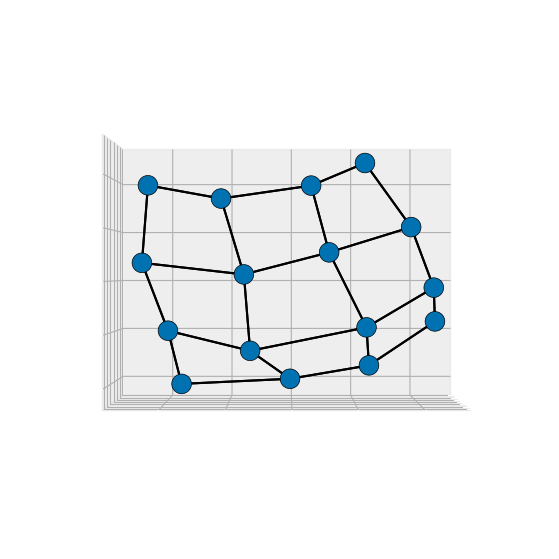

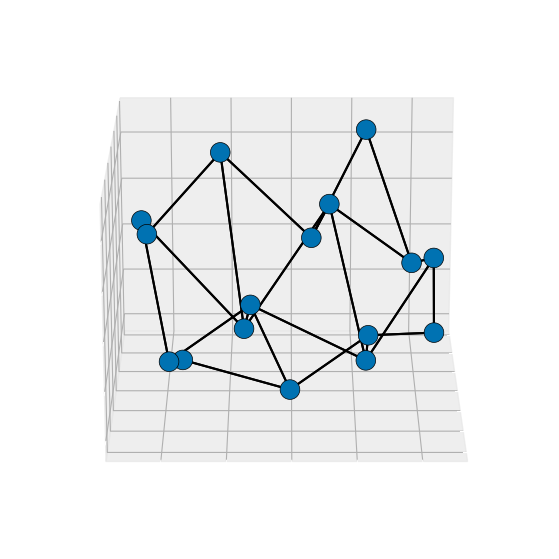

In [46]:
%matplotlib inline
# %matplotlib widget

grid_v3_raw_elev = 0
grid_v3_raw_azim = 0
grid_v3_raw_roll = 0

# Styled plotting constants for this block
grid_v3_styled_view = {"elev": grid_v3_raw_elev, "azim": grid_v3_raw_azim, "roll": grid_v3_raw_roll}
grid_v3_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v3_reduced_embeddings,
    grid_v3_edge_list,
    title="",
    view=grid_v3_styled_view,
    root_node_index=grid_v3_root_node_index,
    axis_permutation=grid_v3_styled_axis_permutation,
);

################
#Another Angle
################

grid_v3_raw_elev = 20
grid_v3_raw_azim = 0
grid_v3_raw_roll = 0

# Styled plotting constants for this block
grid_v3_styled_view = {"elev": grid_v3_raw_elev, "azim": grid_v3_raw_azim, "roll": grid_v3_raw_roll}
grid_v3_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v3_reduced_embeddings,
    grid_v3_edge_list,
    title="",
    view=grid_v3_styled_view,
    root_node_index=grid_v3_root_node_index,
    axis_permutation=grid_v3_styled_axis_permutation,
);


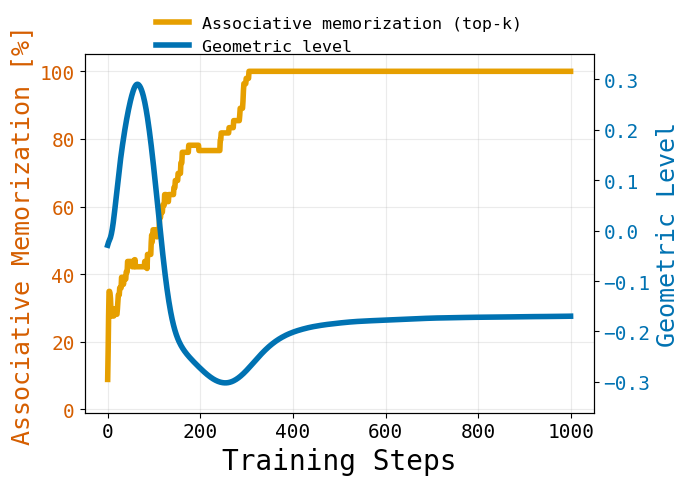

In [47]:
# Line-plot constants for this block
grid_v3_line_plot_title = ""

grid_v3_curve_steps, grid_v3_curve_associative, grid_v3_curve_geometric = compute_associative_geometric_curves(
    grid_v3_embedding_history,
    grid_v3_topk_recovery_history,
    grid_v3_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_v3_curve_steps,
    associative_scores=grid_v3_curve_associative,
    geometric_scores=grid_v3_curve_geometric,
    title=grid_v3_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `grid_heatmap_epoch` to one of the highest geometric_level epochs.

Grid heatmap epoch: 999
Grid heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14 15


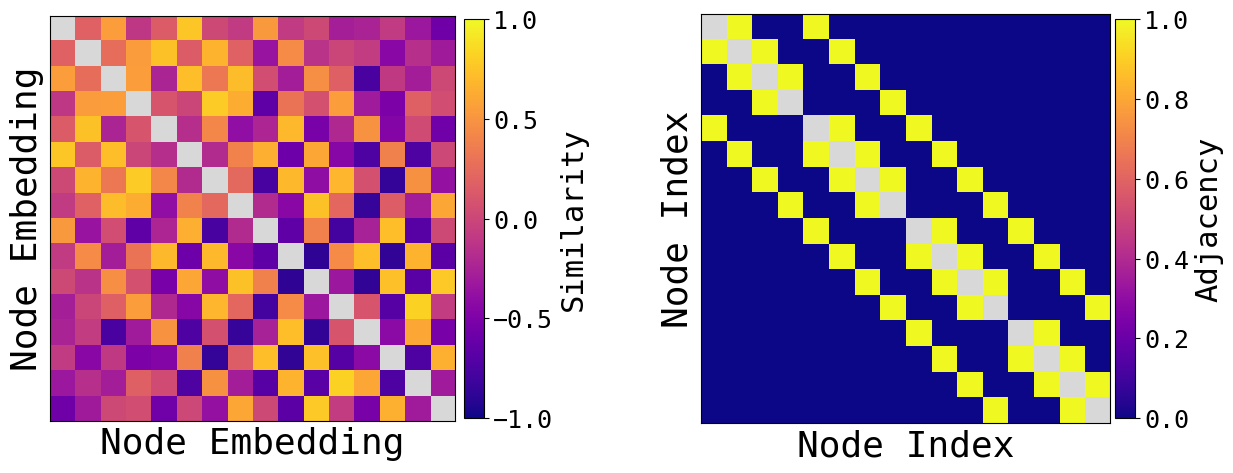

In [48]:
# Heatmap constants for this block
grid_v3_heatmap_graph_type = grid_v3_context.args.graph_type
grid_v3_heatmap_epoch = -1
grid_v3_heatmap_cmap_name = "plasma"
grid_v3_heatmap_wspace = 0.5

grid_v3_heatmap_embeddings, grid_v3_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=grid_v3_embedding_history,
    fallback_embeddings=grid_v3_node_embeddings,
    requested_step=grid_v3_heatmap_epoch,
)
print("Grid heatmap epoch:", grid_v3_heatmap_resolved_epoch)
grid_v3_heatmap_order = list(range(grid_v3_heatmap_embeddings.shape[0]))
print("Grid heatmap order rows:")
for row_start in range(0, len(grid_v3_heatmap_order), 4):
    row = grid_v3_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=grid_v3_heatmap_embeddings,
    edge_list=grid_v3_edge_list,
    graph_type=grid_v3_heatmap_graph_type,
    root_node_index=grid_v3_root_node_index,
    custom_order=grid_v3_heatmap_order,
    cmap_name=grid_v3_heatmap_cmap_name,
    wspace=grid_v3_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [49]:
# Laplacian geometry constants for this block
grid_v3_laplacian_axis_indices = (-2, -3, -4)
grid_v3_spectral_state = build_graph_spectral_state(
    edge_list=grid_v3_edge_list,
    node_count=grid_v3_node_embeddings.shape[0],
)

/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_spectral.py:56: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors = np.asarray(eigenvectors[:, sorted_indices], dtype=np.float64)


Grid normalized eigenvalues:
 [ 1.     1.     0.646  0.423  0.42   0.    -0.    -0.    -0.    -0.42
 -0.423 -0.646 -1.    -1.    -1.274]


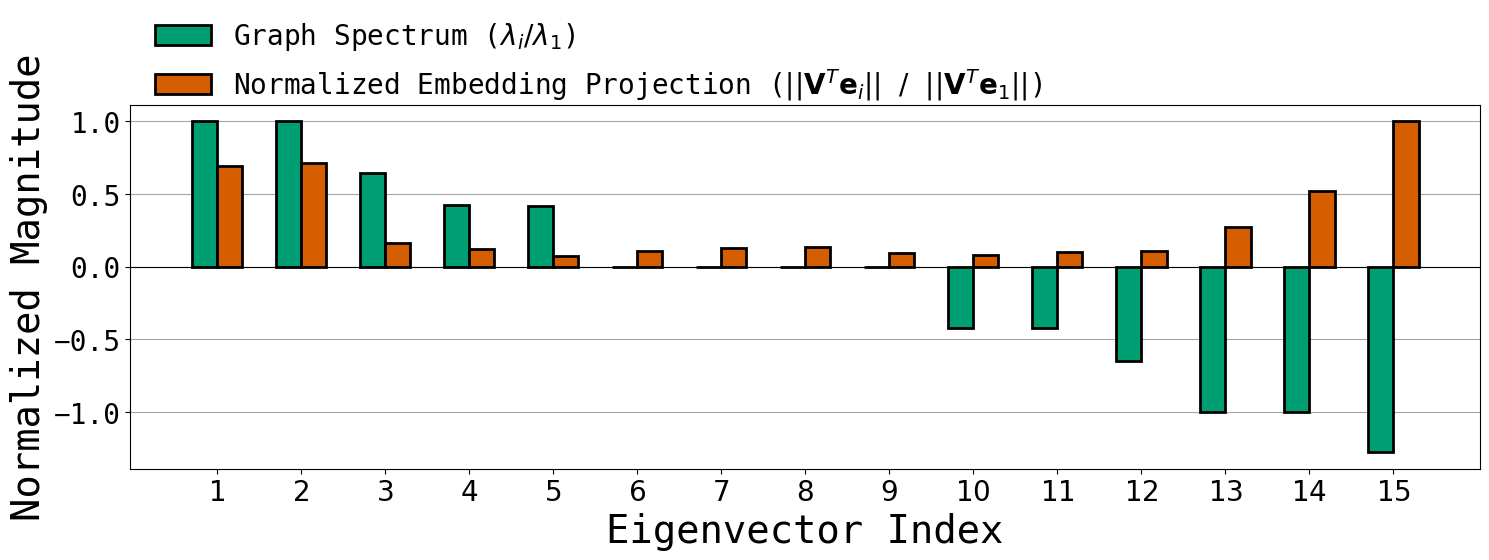

In [50]:
# Spectral-bias constants for this block
grid_v3_spectral_drop_top_eigenvector = True
grid_v3_spectral_reorder_prefix = None
grid_v3_spectral_cutoff = None
grid_v3_spectral_figsize = (15.0, 6.0)
grid_v3_spectral_legend_anchor = (0.0, 1.3)

grid_v3_norm_eigenvalues, grid_v3_norm_projections = compute_spectral_bias_from_state(
    embeddings=grid_v3_node_embeddings,
    spectral_state=grid_v3_spectral_state,
    drop_top_eigenvector=grid_v3_spectral_drop_top_eigenvector,
    reorder_prefix=grid_v3_spectral_reorder_prefix,
)

print("Grid normalized eigenvalues:\n", grid_v3_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=grid_v3_norm_eigenvalues,
    norm_projections=grid_v3_norm_projections,
    title="",
    cutoff=grid_v3_spectral_cutoff,
    figsize=grid_v3_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=grid_v3_spectral_legend_anchor,
    save=True,
    filename=f"{grid_v3_context.args.graph_type}_{grid_v3_context.args.model_architecture_label}_eigen_projection_v3"
);


## 4) Tiny Grid (No Weight Decay/Dropout -- Tiny LR)


In [51]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [52]:
grid_v4_seed = 7

grid_v4_train_from_scratch = True
grid_v4_checkpoint_path = ""
grid_v4_embedding_history_path = ""
grid_v4_topk_history_path = ""
grid_v4_dataset_overwrite = False

grid_v4_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.0001,
    "--edge_memorization_epochs": 10000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0., # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": False,
}


In [53]:
grid_v4_context = build_transformer_section_context(
    grid_v4_cli_config,
    seed=grid_v4_seed,
    dataset_overwrite=grid_v4_dataset_overwrite,
)

grid_v4_resolved_checkpoint_path = train_or_load_edge_model(
    grid_v4_context,
    train_from_scratch=grid_v4_train_from_scratch,
    checkpoint_path=grid_v4_checkpoint_path,
)

print("Run name:", grid_v4_context.args.run_name)
print("Checkpoint:", grid_v4_resolved_checkpoint_path)
print("Pretrain file:", grid_v4_context.pretrain_path)
print("Train file:", grid_v4_context.train_path)
print("Test file:", grid_v4_context.test_path)
print("Archived checkpoint:", grid_v4_context.checkpoint_path)
print("Embedding history pickle:", grid_v4_context.embedding_history_path)
print("Top-k pickle:", grid_v4_context.topk_history_path)
print("Manifest:", grid_v4_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datas

Edge Epoch 1/10000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 79.33it/s]
Edge Epoch 2/10000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 53.64it/s]
Edge Epoch 3/10000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 54.84it/s]
Edge Epoch 4/10000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 52.45it/s]
Edge Epoch 5/10000 | Loss: 3.2188 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00, 34.35it/s]
Edge Epoch 6/10000 | Loss: 3.2188 | Acc: 2.08%: 100%|██████████| 1/1 [00:00<00:00, 39.00it/s]
Edge Epoch 7/10000 | Loss: 3.2188 | Acc: 2.08%: 100%|██████████| 1/1 [00:00<00:00, 43.06it/s]
Edge Epoch 8/10000 | Loss: 3.2188 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 48.39it/s]
Edge Epoch 9/10000 | Loss: 3.2188 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 45.06it/s]
Edge Epoch 10/10000 | Loss: 3.2188 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 37.19it/s]
Edge Epoch 11/10000 | Loss: 3.2188 | Acc: 4.17%: 100%|█████


Edge accuracy improved to 25.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819_edge_memorization_best.pt


Edge Epoch 1502/10000 | Loss: 1.9242 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 61.66it/s]
Edge Epoch 1503/10000 | Loss: 1.9242 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 61.56it/s]
Edge Epoch 1504/10000 | Loss: 1.9225 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 64.62it/s]
Edge Epoch 1505/10000 | Loss: 1.9211 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 61.07it/s]
Edge Epoch 1506/10000 | Loss: 1.9202 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 48.95it/s]
Edge Epoch 1507/10000 | Loss: 1.9189 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 57.18it/s]
Edge Epoch 1508/10000 | Loss: 1.9202 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 50.65it/s]
Edge Epoch 1509/10000 | Loss: 1.9196 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 50.87it/s]
Edge Epoch 1510/10000 | Loss: 1.9193 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 59.18it/s]
Edge Epoch 1511/10000 | Loss: 1.9168 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 66.65it/s]
Edge Epoch 1512/1000


Edge accuracy improved to 27.08%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819_edge_memorization_best.pt


...


Edge accuracy improved to 31.25%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819_edge_memorization_best.pt


Edge Epoch 3507/10000 | Loss: 1.5212 | Acc: 29.17%: 100%|██████████| 1/1 [00:00<00:00, 40.71it/s]
Edge Epoch 3508/10000 | Loss: 1.5202 | Acc: 29.17%: 100%|██████████| 1/1 [00:00<00:00, 49.35it/s]
Edge Epoch 3509/10000 | Loss: 1.5194 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 46.53it/s]
Edge Epoch 3510/10000 | Loss: 1.5190 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 59.92it/s]
Edge Epoch 3511/10000 | Loss: 1.5197 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 39.60it/s]
Edge Epoch 3512/10000 | Loss: 1.5186 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 54.86it/s]
Edge Epoch 3513/10000 | Loss: 1.5179 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 46.83it/s]
Edge Epoch 3514/10000 | Loss: 1.5169 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 54.99it/s]
Edge Epoch 3515/10000 | Loss: 1.5163 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 56.89it/s]
Edge Epoch 3516/10000 | Loss: 1.5163 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 75.18it/s]
Edge Epoch 3517/1000


Edge accuracy improved to 33.33%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819_edge_memorization_best.pt


Edge Epoch 3605/10000 | Loss: 1.4748 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 45.24it/s]
Edge Epoch 3606/10000 | Loss: 1.4735 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 48.48it/s]
Edge Epoch 3607/10000 | Loss: 1.4740 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 72.72it/s]
Edge Epoch 3608/10000 | Loss: 1.4741 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 56.67it/s]
Edge Epoch 3609/10000 | Loss: 1.4738 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 60.78it/s]
Edge Epoch 3610/10000 | Loss: 1.4744 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 72.68it/s]
Edge Epoch 3611/10000 | Loss: 1.4728 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 44.74it/s]
Edge Epoch 3612/10000 | Loss: 1.4715 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 73.56it/s]
Edge Epoch 3613/10000 | Loss: 1.4709 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 57.71it/s]
Edge Epoch 3614/10000 | Loss: 1.4712 | Acc: 31.25%: 100%|██████████| 1/1 [00:00<00:00, 47.77it/s]
Edge Epoch 3615/1000


Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p0001x0p005_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260403-113819_edge_memorization_final.pt
Pretrain file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
Train file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
Test file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny

In [57]:
grid_v4_eval_metrics = evaluate_edge_and_path(grid_v4_context)

print_evaluation_report("Tiny Grid (V4)", grid_v4_eval_metrics)


Edge Memorization | Loss: 1.1315 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 32.33it/s]


Edge Memorization | Loss: 1.1315 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 82.98it/s]

Tiny Grid (V4) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [58]:
grid_v4_node_embeddings, grid_v4_edge_list, grid_v4_root_node_index = collect_embeddings_and_edges(grid_v4_context)

grid_v4_embedding_history, grid_v4_topk_recovery_history = load_analysis_histories(
    grid_v4_context,
    grid_v4_edge_list,
    embedding_history_path=grid_v4_embedding_history_path,
    topk_history_path=grid_v4_topk_history_path,
)

if not grid_v4_embedding_history:
    grid_v4_embedding_history = {0: grid_v4_node_embeddings}
if not grid_v4_topk_recovery_history:
    grid_v4_topk_recovery_history = {0: grid_v4_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_v4_node_embeddings.shape)
print("Number of edges:", len(grid_v4_edge_list))
print("Root node index:", grid_v4_root_node_index)
print("Embedding history steps:", len(grid_v4_embedding_history))
print("Top-k history steps:", len(grid_v4_topk_recovery_history))


Node embedding shape: (16, 32)
Number of edges: 48
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [59]:
# Reduction config for this block (kept local to reduction stage)
grid_v4_use_umap = False
grid_v4_reduction_dim = 5
grid_v4_umap_n_neighbors = 4
grid_v4_umap_min_dist = 0.3

grid_v4_reduced_full, grid_v4_reduced_embeddings = reduce_embeddings_for_plot(
    grid_v4_node_embeddings,
    use_umap=grid_v4_use_umap,
    reduction_dim=grid_v4_reduction_dim,
    seed=grid_v4_seed,
    umap_n_neighbors=grid_v4_umap_n_neighbors,
    umap_min_dist=grid_v4_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_v4_reduced_embeddings = grid_v4_reduced_full[:, :3]
print("Reduced full shape:", grid_v4_reduced_full.shape)
print("Reduced xyz shape:", grid_v4_reduced_embeddings.shape)


Reduced full shape: (16, 5)
Reduced xyz shape: (16, 3)


### Geometry Plot

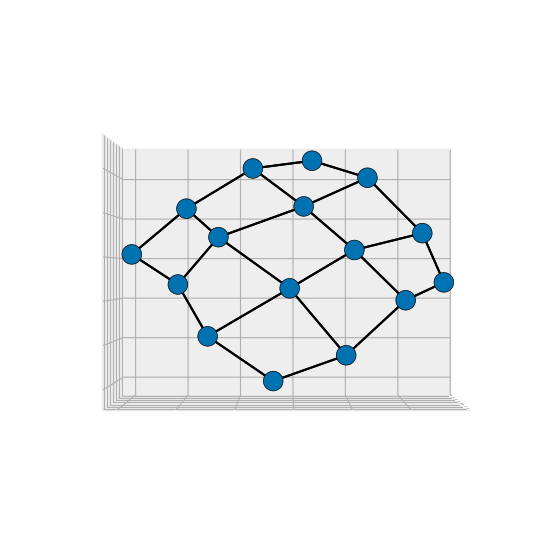

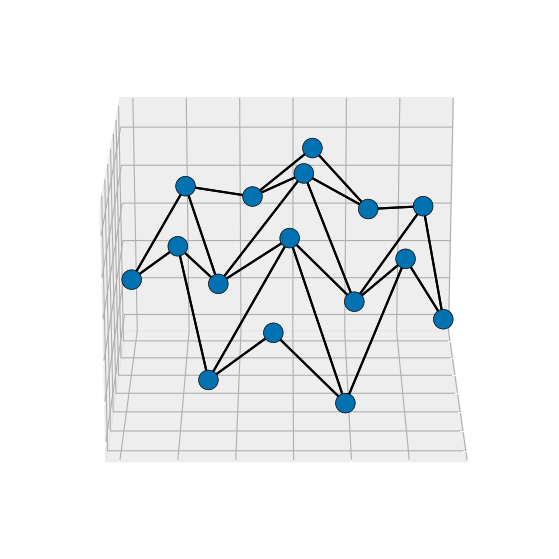

In [60]:
%matplotlib inline
# %matplotlib widget

grid_v4_raw_elev = 0
grid_v4_raw_azim = 0
grid_v4_raw_roll = 0

# Styled plotting constants for this block
grid_v4_styled_view = {"elev": grid_v4_raw_elev, "azim": grid_v4_raw_azim, "roll": grid_v4_raw_roll}
grid_v4_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v4_reduced_embeddings,
    grid_v4_edge_list,
    title="",
    view=grid_v4_styled_view,
    root_node_index=grid_v4_root_node_index,
    axis_permutation=grid_v4_styled_axis_permutation,
);


################
#Another Angle
################

grid_v4_raw_elev = 20
grid_v4_raw_azim = 0
grid_v4_raw_roll = 0

# Styled plotting constants for this block
grid_v4_styled_view = {"elev": grid_v4_raw_elev, "azim": grid_v4_raw_azim, "roll": grid_v4_raw_roll}
grid_v4_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v4_reduced_embeddings,
    grid_v4_edge_list,
    title="",
    view=grid_v4_styled_view,
    root_node_index=grid_v4_root_node_index,
    axis_permutation=grid_v4_styled_axis_permutation,
);

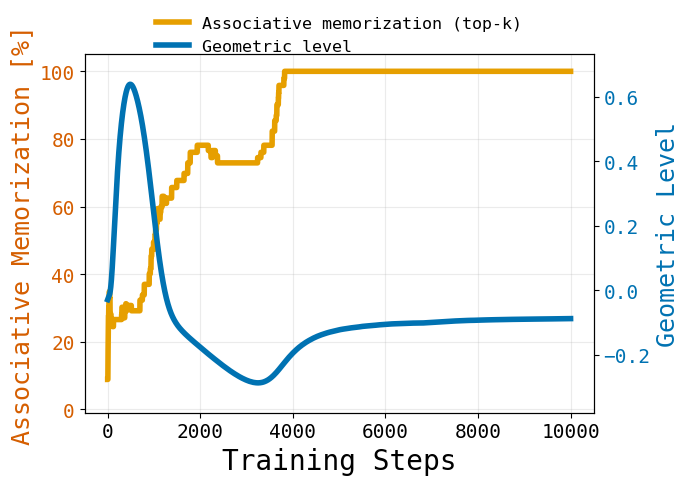

In [61]:
# Line-plot constants for this block
grid_v4_line_plot_title = ""

grid_v4_curve_steps, grid_v4_curve_associative, grid_v4_curve_geometric = compute_associative_geometric_curves(
    grid_v4_embedding_history,
    grid_v4_topk_recovery_history,
    grid_v4_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_v4_curve_steps,
    associative_scores=grid_v4_curve_associative,
    geometric_scores=grid_v4_curve_geometric,
    title=grid_v4_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `grid_heatmap_epoch` to one of the highest geometric_level epochs.

Grid heatmap epoch: 9999
Grid heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14 15


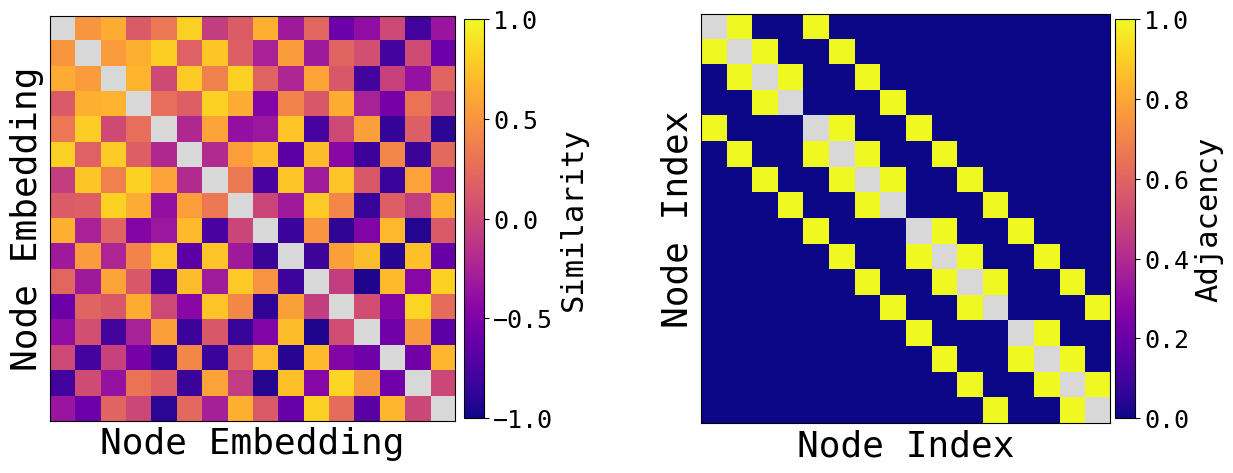

In [62]:
# Heatmap constants for this block
grid_v4_heatmap_graph_type = grid_v4_context.args.graph_type
grid_v4_heatmap_epoch = -1
grid_v4_heatmap_cmap_name = "plasma"
grid_v4_heatmap_wspace = 0.5

grid_v4_heatmap_embeddings, grid_v4_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=grid_v4_embedding_history,
    fallback_embeddings=grid_v4_node_embeddings,
    requested_step=grid_v4_heatmap_epoch,
)
print("Grid heatmap epoch:", grid_v4_heatmap_resolved_epoch)
grid_v4_heatmap_order = list(range(grid_v4_heatmap_embeddings.shape[0]))
print("Grid heatmap order rows:")
for row_start in range(0, len(grid_v4_heatmap_order), 4):
    row = grid_v4_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=grid_v4_heatmap_embeddings,
    edge_list=grid_v4_edge_list,
    graph_type=grid_v4_heatmap_graph_type,
    root_node_index=grid_v4_root_node_index,
    custom_order=grid_v4_heatmap_order,
    cmap_name=grid_v4_heatmap_cmap_name,
    wspace=grid_v4_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [63]:
# Laplacian geometry constants for this block
grid_v4_laplacian_axis_indices = (-2, -3, -4)
grid_v4_spectral_state = build_graph_spectral_state(
    edge_list=grid_v4_edge_list,
    node_count=grid_v4_node_embeddings.shape[0],
)

/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_spectral.py:56: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvectors = np.asarray(eigenvectors[:, sorted_indices], dtype=np.float64)


Grid normalized eigenvalues:
 [ 1.     1.     0.646  0.423  0.42   0.    -0.    -0.    -0.    -0.42
 -0.423 -0.646 -1.    -1.    -1.274]


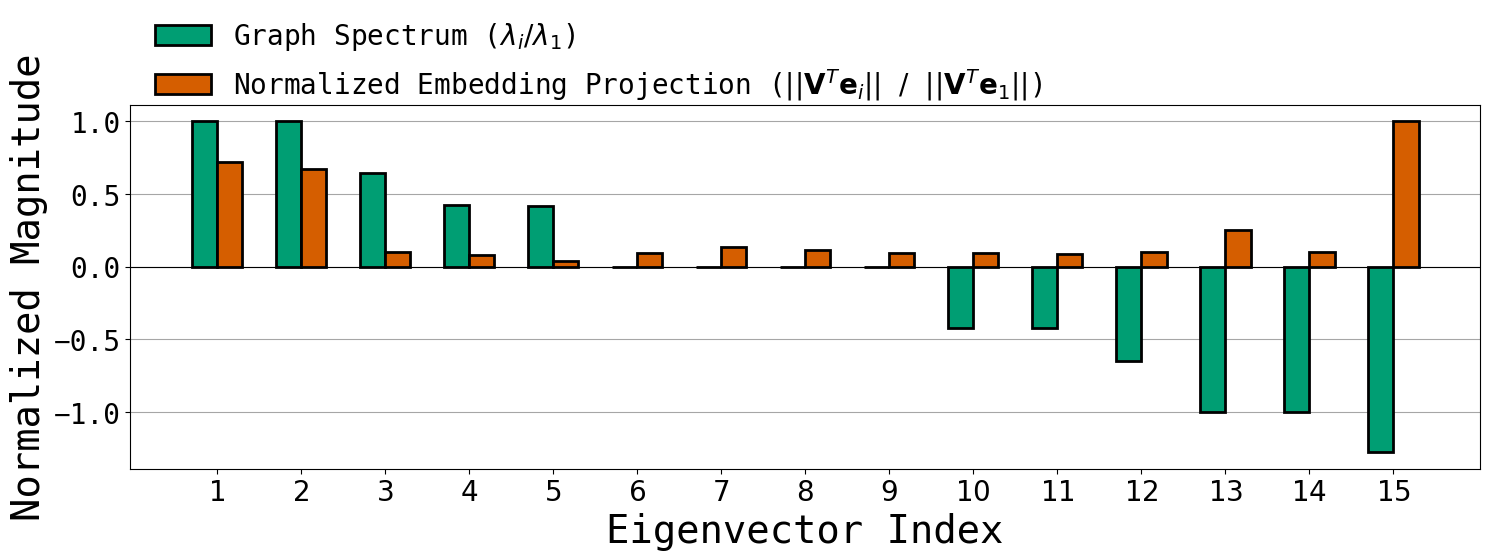

In [64]:
# Spectral-bias constants for this block
grid_v4_spectral_drop_top_eigenvector = True
grid_v4_spectral_reorder_prefix = None
grid_v4_spectral_cutoff = None
grid_v4_spectral_figsize = (15.0, 6.0)
grid_v4_spectral_legend_anchor = (0.0, 1.3)

grid_v4_norm_eigenvalues, grid_v4_norm_projections = compute_spectral_bias_from_state(
    embeddings=grid_v4_node_embeddings,
    spectral_state=grid_v4_spectral_state,
    drop_top_eigenvector=grid_v4_spectral_drop_top_eigenvector,
    reorder_prefix=grid_v4_spectral_reorder_prefix,
)

print("Grid normalized eigenvalues:\n", grid_v4_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=grid_v4_norm_eigenvalues,
    norm_projections=grid_v4_norm_projections,
    title="",
    cutoff=grid_v4_spectral_cutoff,
    figsize=grid_v4_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=grid_v4_spectral_legend_anchor,
    save=True,
    filename=f"{grid_v4_context.args.graph_type}_{grid_v4_context.args.model_architecture_label}_eigen_projection"
);


## 5) Tiny Grid with Self-Edges (Reasonable LR)


In [29]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [65]:
grid_v5_seed = 7

grid_v5_train_from_scratch = True
grid_v5_checkpoint_path = ""
grid_v5_embedding_history_path = ""
grid_v5_topk_history_path = ""
grid_v5_dataset_overwrite = False

grid_v5_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0., # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True, # DIFFERENT FROM V1-V4, ADDS SELF-EDGES
}


In [66]:
grid_v5_context = build_transformer_section_context(
    grid_v5_cli_config,
    seed=grid_v5_seed,
    dataset_overwrite=grid_v5_dataset_overwrite,
)

grid_v5_resolved_checkpoint_path = train_or_load_edge_model(
    grid_v5_context,
    train_from_scratch=grid_v5_train_from_scratch,
    checkpoint_path=grid_v5_checkpoint_path,
)

print("Run name:", grid_v5_context.args.run_name)
print("Checkpoint:", grid_v5_resolved_checkpoint_path)
print("Pretrain file:", grid_v5_context.pretrain_path)
print("Train file:", grid_v5_context.train_path)
print("Test file:", grid_v5_context.test_path)
print("Archived checkpoint:", grid_v5_context.checkpoint_path)
print("Embedding history pickle:", grid_v5_context.embedding_history_path)
print("Top-k pickle:", grid_v5_context.topk_history_path)
print("Manifest:", grid_v5_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datas

Edge Epoch 1/1000 | Loss: 3.2188 | Acc: 1.56%: 100%|██████████| 1/1 [00:00<00:00, 27.56it/s]
Edge Epoch 2/1000 | Loss: 3.2188 | Acc: 4.69%: 100%|██████████| 1/1 [00:00<00:00, 34.36it/s]
Edge Epoch 3/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|██████████| 1/1 [00:00<00:00, 34.22it/s]
Edge Epoch 4/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|██████████| 1/1 [00:00<00:00, 32.58it/s]
Edge Epoch 5/1000 | Loss: 3.2188 | Acc: 9.38%: 100%|██████████| 1/1 [00:00<00:00, 26.66it/s]
Edge Epoch 6/1000 | Loss: 3.2188 | Acc: 9.38%: 100%|██████████| 1/1 [00:00<00:00, 45.72it/s]
Edge Epoch 7/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|██████████| 1/1 [00:00<00:00, 76.78it/s]
Edge Epoch 8/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|██████████| 1/1 [00:00<00:00, 68.91it/s]
Edge Epoch 9/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|██████████| 1/1 [00:00<00:00, 99.45it/s]
Edge Epoch 10/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|██████████| 1/1 [00:00<00:00, 61.56it/s]
Edge Epoch 11/1000 | Loss: 3.2188 | Acc: 10.94%: 100%|█████████


Edge accuracy improved to 25.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260403-114530/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260403-114530_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 1.4117 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 41.32it/s]



Edge memorization complete. Best edge accuracy: 25.00%
Run name: in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260403-114530
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_grid-r4-c4-n16_gpt-L1-D32-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p001x0p005_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260403-114530_edge_memorization_final.pt
Pretrain file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
Train file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_train_12.txt
Test file: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_g

In [67]:
grid_v5_eval_metrics = evaluate_edge_and_path(grid_v5_context)

print_evaluation_report("Tiny Grid (V5)", grid_v5_eval_metrics)


Edge Memorization | Loss: 1.4117 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 52.26it/s]


Edge Memorization | Loss: 1.4117 | Acc: 25.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 94.71it/s]

Tiny Grid (V5) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [68]:
grid_v5_node_embeddings, grid_v5_edge_list, grid_v5_root_node_index = collect_embeddings_and_edges(grid_v5_context)

grid_v5_embedding_history, grid_v5_topk_recovery_history = load_analysis_histories(
    grid_v5_context,
    grid_v5_edge_list,
    embedding_history_path=grid_v5_embedding_history_path,
    topk_history_path=grid_v5_topk_history_path,
)

if not grid_v5_embedding_history:
    grid_v5_embedding_history = {0: grid_v5_node_embeddings}
if not grid_v5_topk_recovery_history:
    grid_v5_topk_recovery_history = {0: grid_v5_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_v5_node_embeddings.shape)
print("Number of edges:", len(grid_v5_edge_list))
print("Root node index:", grid_v5_root_node_index)
print("Embedding history steps:", len(grid_v5_embedding_history))
print("Top-k history steps:", len(grid_v5_topk_recovery_history))


Node embedding shape: (16, 32)
Number of edges: 64
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [69]:
# Reduction config for this block (kept local to reduction stage)
grid_v5_use_umap = False
grid_v5_reduction_dim = 5
grid_v5_umap_n_neighbors = 4
grid_v5_umap_min_dist = 0.3

grid_v5_reduced_full, grid_v5_reduced_embeddings = reduce_embeddings_for_plot(
    grid_v5_node_embeddings,
    use_umap=grid_v5_use_umap,
    reduction_dim=grid_v5_reduction_dim,
    seed=grid_v5_seed,
    umap_n_neighbors=grid_v5_umap_n_neighbors,
    umap_min_dist=grid_v5_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_v5_reduced_embeddings = grid_v5_reduced_full[:, :3]
print("Reduced full shape:", grid_v5_reduced_full.shape)
print("Reduced xyz shape:", grid_v5_reduced_embeddings.shape)


Reduced full shape: (16, 5)
Reduced xyz shape: (16, 3)


### Geometry Plot

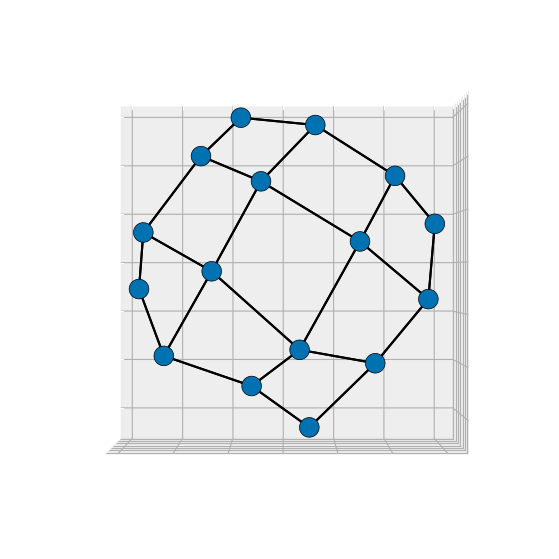

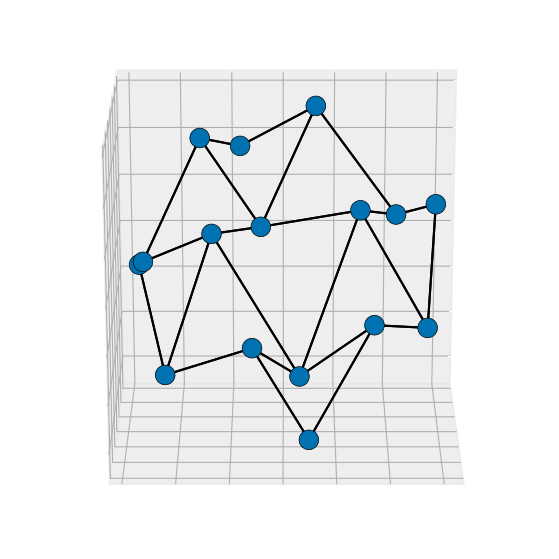

In [77]:
%matplotlib inline
# %matplotlib widget

grid_v5_raw_elev = 90
grid_v5_raw_azim = 0
grid_v5_raw_roll = 0

# Styled plotting constants for this block
grid_v5_styled_view = {"elev": grid_v5_raw_elev, "azim": grid_v5_raw_azim, "roll": grid_v5_raw_roll}
grid_v5_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v5_reduced_embeddings,
    grid_v5_edge_list,
    title="",
    view=grid_v5_styled_view,
    root_node_index=grid_v5_root_node_index,
    axis_permutation=grid_v5_styled_axis_permutation,
);

################
#Another Angle
################

grid_v5_raw_elev = 110
grid_v5_raw_azim = 0
grid_v5_raw_roll = 0

# Styled plotting constants for this block
grid_v5_styled_view = {"elev": grid_v5_raw_elev, "azim": grid_v5_raw_azim, "roll": grid_v5_raw_roll}
grid_v5_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_v5_reduced_embeddings,
    grid_v5_edge_list,
    title="",
    view=grid_v5_styled_view,
    root_node_index=grid_v5_root_node_index,
    axis_permutation=grid_v5_styled_axis_permutation,
);



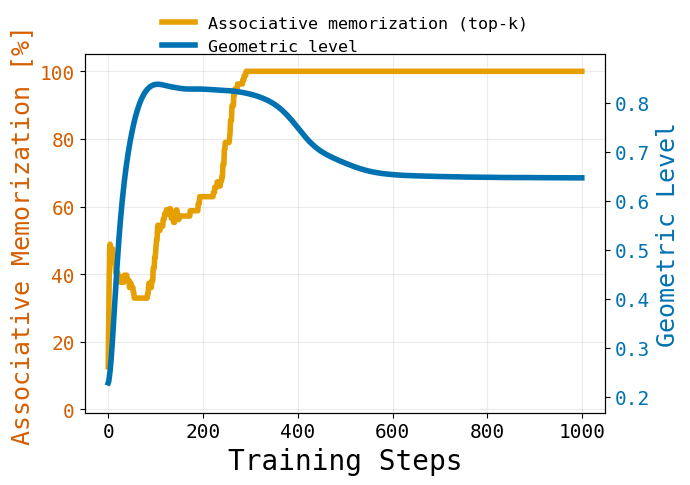

In [78]:
# Line-plot constants for this block
grid_v5_line_plot_title = ""

grid_v5_curve_steps, grid_v5_curve_associative, grid_v5_curve_geometric = compute_associative_geometric_curves(
    grid_v5_embedding_history,
    grid_v5_topk_recovery_history,
    grid_v5_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_v5_curve_steps,
    associative_scores=grid_v5_curve_associative,
    geometric_scores=grid_v5_curve_geometric,
    title=grid_v5_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `grid_heatmap_epoch` to one of the highest geometric_level epochs.

Grid heatmap epoch: 999
Grid heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14 15


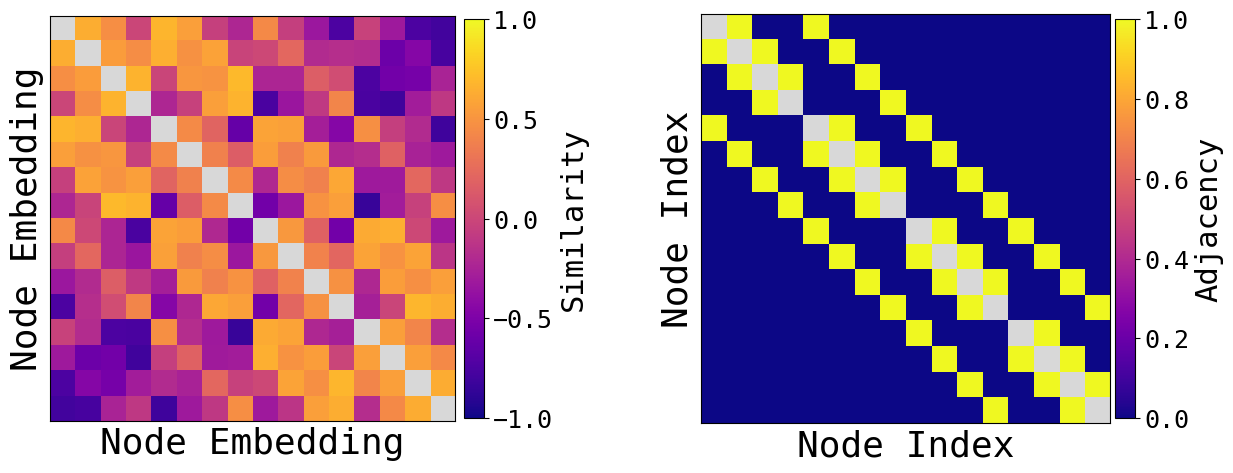

In [79]:
# Heatmap constants for this block
grid_v5_heatmap_graph_type = grid_v5_context.args.graph_type
grid_v5_heatmap_epoch = -1
grid_v5_heatmap_cmap_name = "plasma"
grid_v5_heatmap_wspace = 0.5

grid_v5_heatmap_embeddings, grid_v5_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=grid_v5_embedding_history,
    fallback_embeddings=grid_v5_node_embeddings,
    requested_step=grid_v5_heatmap_epoch,
)
print("Grid heatmap epoch:", grid_v5_heatmap_resolved_epoch)
grid_v5_heatmap_order = list(range(grid_v5_heatmap_embeddings.shape[0]))
print("Grid heatmap order rows:")
for row_start in range(0, len(grid_v5_heatmap_order), 4):
    row = grid_v5_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=grid_v5_heatmap_embeddings,
    edge_list=grid_v5_edge_list,
    graph_type=grid_v5_heatmap_graph_type,
    root_node_index=grid_v5_root_node_index,
    custom_order=grid_v5_heatmap_order,
    cmap_name=grid_v5_heatmap_cmap_name,
    wspace=grid_v5_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [80]:
# Laplacian geometry constants for this block
grid_v5_laplacian_axis_indices = (-2, -3, -4)
grid_v5_spectral_state = build_graph_spectral_state(
    edge_list=grid_v5_edge_list,
    node_count=grid_v5_node_embeddings.shape[0],
)

Grid v5 normalized eigenvalues:
 [ 1.     1.     0.772  0.592  0.592  0.333  0.333  0.266  0.266 -0.
 -0.001 -0.084 -0.376 -0.376 -0.613]


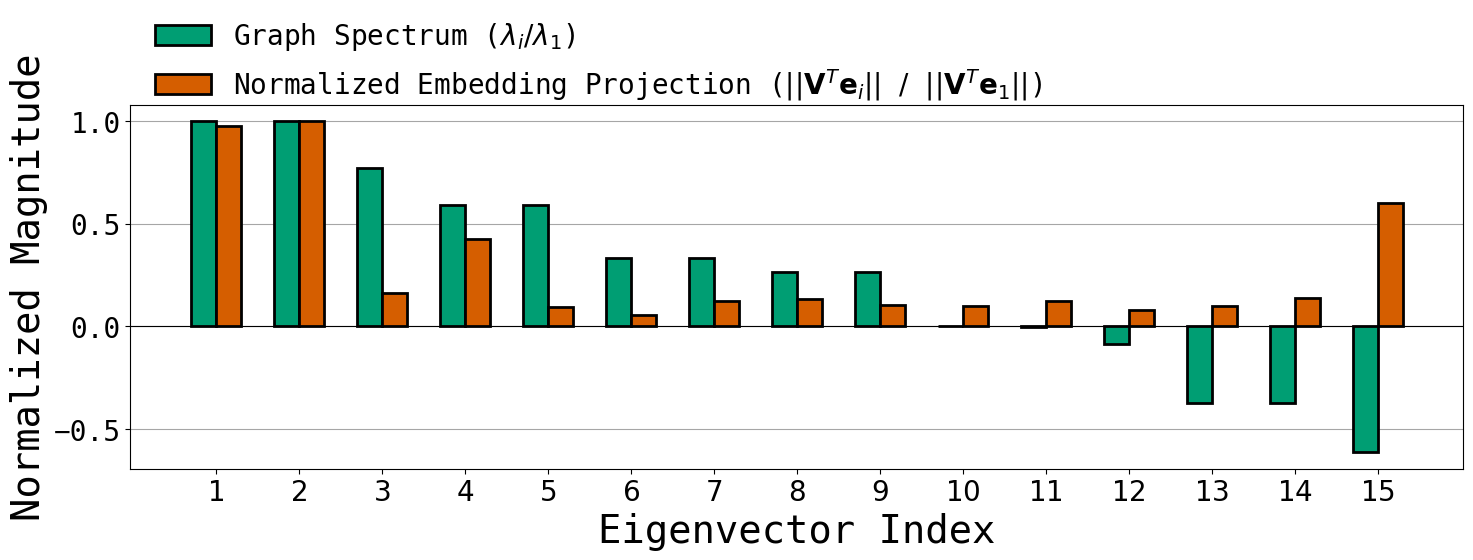

In [81]:
# Spectral-bias constants for this block
grid_v5_spectral_drop_top_eigenvector = True
grid_v5_spectral_reorder_prefix = (1, 0)
grid_v5_spectral_cutoff = None
grid_v5_spectral_figsize = (15.0, 6.0)
grid_v5_spectral_legend_anchor = (0.0, 1.3)

grid_v5_norm_eigenvalues, grid_v5_norm_projections = compute_spectral_bias_from_state(
    embeddings=grid_v5_node_embeddings,
    spectral_state=grid_v5_spectral_state,
    drop_top_eigenvector=grid_v5_spectral_drop_top_eigenvector,
    reorder_prefix=grid_v5_spectral_reorder_prefix,
)

print("Grid v5 normalized eigenvalues:\n", grid_v5_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=grid_v5_norm_eigenvalues,
    norm_projections=grid_v5_norm_projections,
    title="",
    cutoff=grid_v5_spectral_cutoff,
    figsize=grid_v5_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=grid_v5_spectral_legend_anchor,
    save=True,
    filename=f"{grid_v5_context.args.graph_type}_{grid_v5_context.args.model_architecture_label}_eigen_projection"
);
